<a href="https://colab.research.google.com/github/ahnaT-rid/Spam-SMS-Classifier/blob/main/Copy_of_Spam_SMS_Classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Group Member**
####41230100665 Abdul Aziz
####41230100808 Tahmid Hasan Rafi
####41230100815 Tanha Zaman
####41230100821 Md Alvi Hasan Emon

In [ ]:
import numpy as np
import pandas as pd


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam (2).csv


In [ ]:
import pandas as pd

df = pd.read_csv("spam.csv", encoding='latin-1')

In [ ]:
df.sample(10)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
4980,ham,I said its okay. Sorry,NaN,NaN,NaN
5110,spam,You have 1 new message. Please call 08715205273,NaN,NaN,NaN
5564,ham,Why don't you wait 'til at least wednesday to ...,NaN,NaN,NaN
5432,ham,Thanx a lot 4 ur help!,NaN,NaN,NaN
4937,ham,No it was cancelled yeah baby! Well that sound...,NaN,NaN,NaN
146,spam,FreeMsg Why haven't you replied to my text? I'...,NaN,NaN,NaN
787,spam,Ever thought about living a good life with a p...,NaN,NaN,NaN
1515,ham,I wonder if you'll get this text?,NaN,NaN,NaN
4781,ham,"Call me, i am senthil from hsbc.",NaN,NaN,NaN
3973,ham,Roger that. WeÛ÷re probably going to rem in a...,NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)




**1.data cleaning**

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)
df.sample(10)

,v1,v2
706,ham,So when do you wanna gym harri
2097,ham,Are you the cutest girl in the world or what
5146,ham,Oh unintentionally not bad timing. Great. Fing...
869,spam,What do U want for Xmas? How about 100 free te...
4798,ham,I dont know why she.s not getting your messages
1367,ham,"I don't know, same thing that's wrong everyso ..."
1095,ham,Ryder unsold.now gibbs.
3094,ham,Olol i printed out a forum post by a guy with ...
3279,ham,Badrith is only for chennai:)i will surely pic...
255,ham,Don't necessarily expect it to be done before ...


In [ ]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)
df.sample(10)

,target,text
4509,ham,This weekend is fine (an excuse not to do too ...
4774,ham,So many people seems to be special at first si...
5394,ham,I dont know exactly could you ask chechi.
1664,ham,ÌÏ v ma fan...
3489,ham,Huh but i got lesson at 4 lei n i was thinkin ...
3887,ham,ok....take care.umma to you too...
1921,ham,No current and food here. I am alone also
515,ham,S:)no competition for him.
3471,ham,I think IÛ÷m waiting for the same bus! Inform...
817,ham,Also are you bringing galileo or dobby


In [ ]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['target'] = encoder.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df.isnull().sum()

,0
target,0
text,0


In [ ]:
df.duplicated().sum()

np.int64(403)

In [ ]:
df = df.drop_duplicates(keep='first')
df.duplicated().sum()
df.shape

(5169, 2)

**2. EDA ( Exploring Data Analysis)**

In [ ]:

df['target'].value_counts()

,count
target,
0,4516
1,653


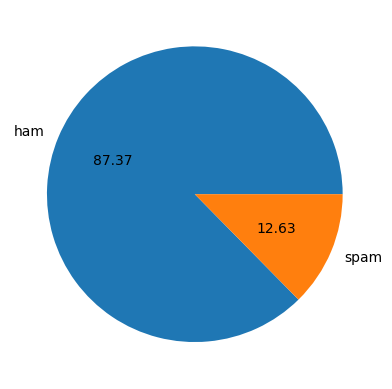

In [ ]:
import matplotlib.pyplot as plt

# Calculate average values for spam messages
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()


In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
df['num_characters'] = df['text'].apply(len)
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df.head()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/tmp/ipykernel_6487/3712008114.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))
/tmp/ipykernel_6487/3712008114.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['num_characters'] = df['text'].apply(len)

,target,text,num_words,num_characters,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",24,111,2
1,0,Ok lar... Joking wif u oni...,8,29,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,155,2
3,0,U dun say so early hor... U c already then say...,13,49,1
4,0,"Nah I don't think he goes to usf, he lives aro...",15,61,1


In [ ]:

df[df['target'] == 0][['num_characters','num_words','num_sentences']].describe() #for hamm

,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 1][['num_characters','num_words','num_sentences']].describe() #for spam

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


<Axes: xlabel='num_characters', ylabel='Count'>

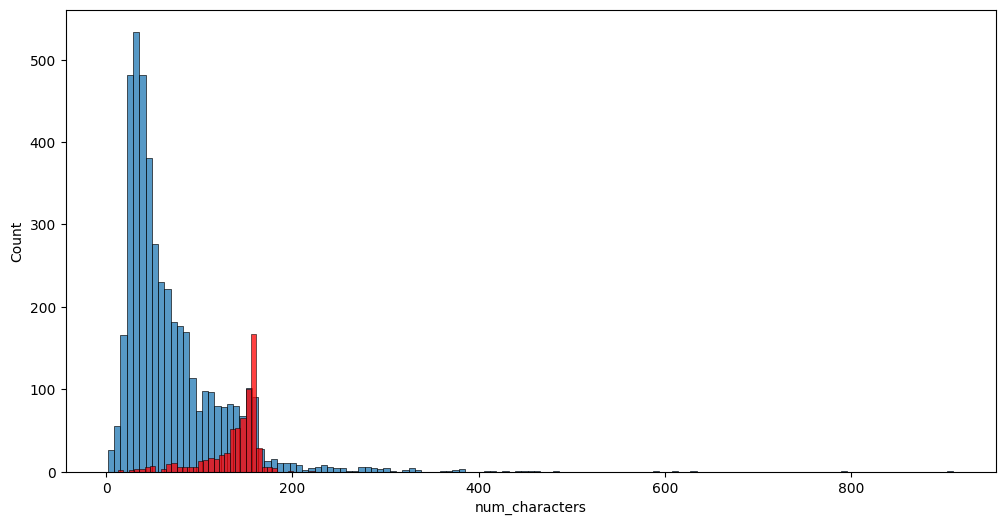

In [ ]:
import seaborn as sns
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'],color='red')

**3. Data Process**

In [ ]:
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [ ]:
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

'gon na home soon want talk stuff anymor tonight k cri enough today'

In [ ]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)
df.head()

,target,text,num_words,num_characters,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",24,111,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,8,29,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,37,155,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,13,49,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",15,61,1,nah think goe usf live around though


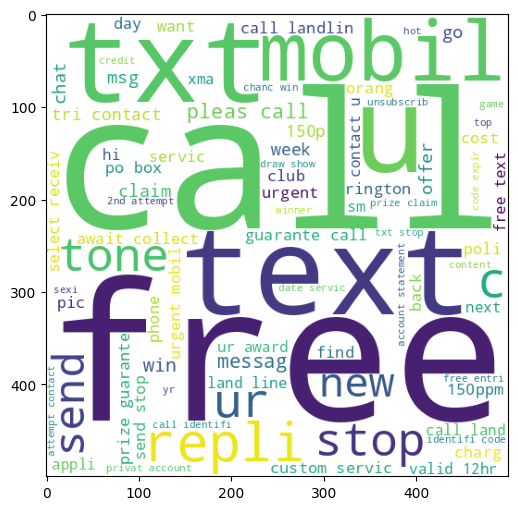

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

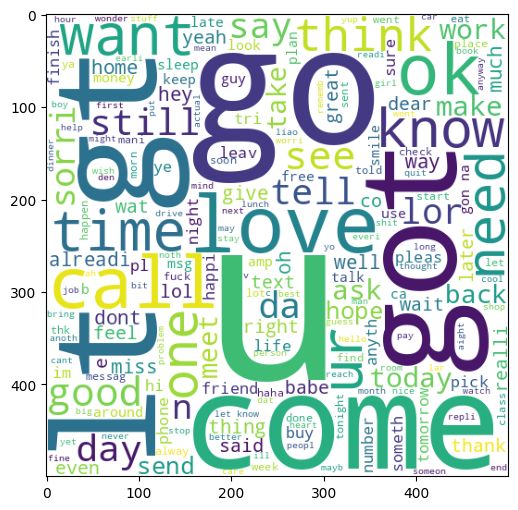

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [ ]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

len(spam_corpus)

9939

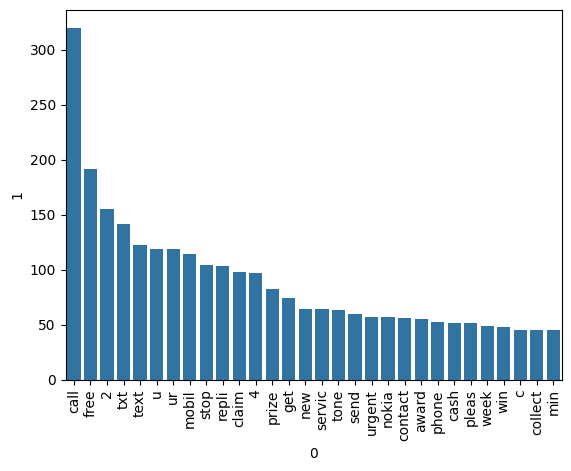

In [ ]:
from collections import Counter
temp_df = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=temp_df[0], y=temp_df[1])
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)
len(ham_corpus)

35404

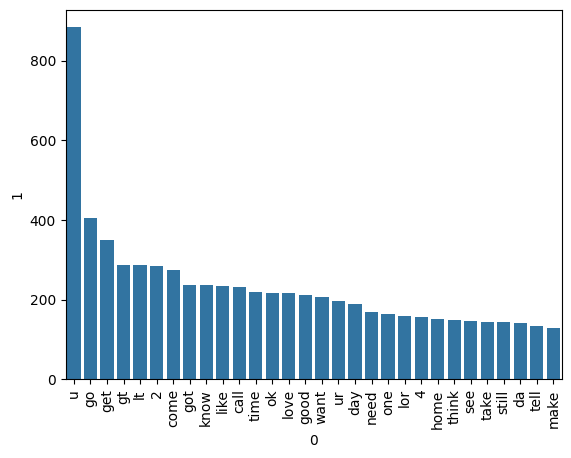

In [ ]:
from collections import Counter
temp_df = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=temp_df[0], y=temp_df[1])
plt.xticks(rotation='vertical')
plt.show()

**4. Model Build**

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=6000)
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
X.shape

(5169, 6000)

In [ ]:
if 'df' in locals():
    if 'transformed_text' in df.columns:
        print("'transformed_text' column exists in df. Here are the first 5 entries:")
        display(df[['text', 'transformed_text']].head())
    else:
        print("'transformed_text' column does not exist in df. Please ensure the transformation cell was run successfully.")
else:
    print("'df' DataFrame is not defined. Please ensure all data loading and preprocessing cells have been executed.")

'transformed_text' column exists in df. Here are the first 5 entries:


,text,transformed_text
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazi avail bugi n great world...
1,Ok lar... Joking wif u oni...,ok lar joke wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entri 2 wkli comp win fa cup final tkt 21...
3,U dun say so early hor... U c already then say...,u dun say earli hor u c alreadi say
4,"Nah I don't think he goes to usf, he lives aro...",nah think goe usf live around though


In [ ]:
y = df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

print('GaussianNB Performance')

gnb.fit(X_train, y_train)
y_pred1 = gnb.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test,y_pred1)}")
print(f"Confusion Matrix:\n{confusion_matrix(y_test,y_pred1)}")
print(f"Precision: {precision_score(y_test,y_pred1)}")

GaussianNB Performance
Accuracy: 0.8762088974854932
Confusion Matrix:
[[793 103]
 [ 25 113]]
Precision: 0.5231481481481481


In [ ]:
mnb.fit(X_train,y_train)
y_pred2 = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred2))
print(confusion_matrix(y_test,y_pred2))
print(precision_score(y_test,y_pred2))

0.9613152804642167
[[896   0]
 [ 40  98]]
1.0


In [ ]:
bnb.fit(X_train,y_train)
y_pred3 = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred3))
print(confusion_matrix(y_test,y_pred3))
print(precision_score(y_test,y_pred3))

0.9680851063829787
[[891   5]
 [ 28 110]]
0.9565217391304348


Now that `X_train` and `X_test` are defined, let's explicitly evaluate the Multinomial Naive Bayes (MNB) model, which was one of the models that previously raised a `NameError`.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [ ]:
train_classifier(svc,X_train,y_train,X_test,y_test)

(0.9777562862669246, 0.9752066115702479)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9777562862669246
Precision -  0.9752066115702479
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9613152804642167
Precision -  1.0
For  DT
Accuracy -  0.9313346228239845
Precision -  0.8252427184466019
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9911504424778761
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8275862068965517
For  BgC
Accuracy -  0.9574468085106383
Precision -  0.8507462686567164
For  ETC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  GBDT
Accuracy -  0.9497098646034816
Precision -  0.93
For  xgb
Accuracy -  0.9748549323017408
Precision -  0.9666666666666667


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.905222,1.000000
2,NB,0.961315,1.000000
5,RF,0.973888,0.991150
0,SVC,0.977756,0.975207
8,ETC,0.975822,0.974790
10,xgb,0.974855,0.966667
4,LR,0.955513,0.960000
9,GBDT,0.949710,0.930000
7,BgC,0.957447,0.850746
6,AdaBoost,0.921663,0.827586


In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")
performance_df1

,Algorithm,variable,value
0,KN,Accuracy,0.905222
1,NB,Accuracy,0.961315
2,RF,Accuracy,0.973888
3,SVC,Accuracy,0.977756
4,ETC,Accuracy,0.975822
5,xgb,Accuracy,0.974855
6,LR,Accuracy,0.955513
7,GBDT,Accuracy,0.949710
8,BgC,Accuracy,0.957447
9,AdaBoost,Accuracy,0.921663


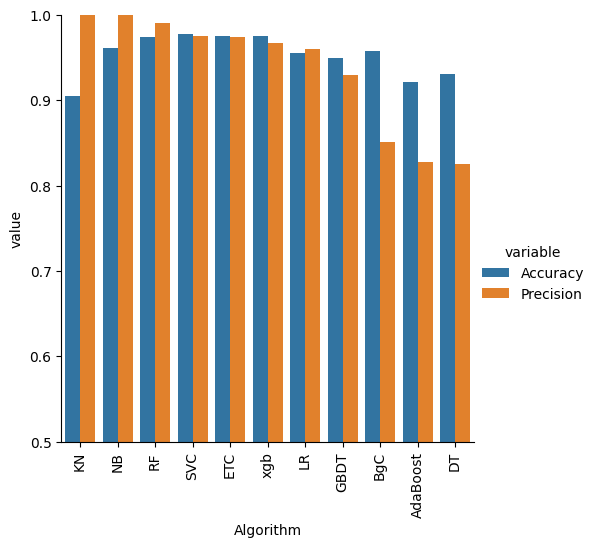

In [ ]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)
new_df = performance_df.merge(temp_df,on='Algorithm')
new_df_scaled = new_df.merge(temp_df,on='Algorithm')
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)
new_df_scaled.merge(temp_df,on='Algorithm')

,Algorithm,Accuracy,Precision,Accuracy_scaling_x,Precision_scaling_x,Accuracy_scaling_y,Precision_scaling_y,Accuracy_num_chars,Precision_num_chars
0,KN,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000,0.905222,1.000000
1,NB,0.961315,1.000000,0.961315,1.000000,0.961315,1.000000,0.961315,1.000000
2,RF,0.973888,0.991150,0.973888,0.991150,0.973888,0.991150,0.973888,0.991150
3,SVC,0.977756,0.975207,0.977756,0.975207,0.977756,0.975207,0.977756,0.975207
4,ETC,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790,0.975822,0.974790
5,xgb,0.974855,0.966667,0.974855,0.966667,0.974855,0.966667,0.974855,0.966667
6,LR,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000,0.955513,0.960000
7,GBDT,0.949710,0.930000,0.949710,0.930000,0.949710,0.930000,0.949710,0.930000
8,BgC,0.957447,0.850746,0.957447,0.850746,0.957447,0.850746,0.957447,0.850746
9,AdaBoost,0.921663,0.827586,0.921663,0.827586,0.921663,0.827586,0.921663,0.827586


In [ ]:
print("Voting Classifier")

Voting Classifier


In [ ]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier, VotingClassifier

svc = SVC(kernel='sigmoid', gamma=1.0, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

voting = VotingClassifier(
    estimators=[
        ('svm', svc),
        ('nb', mnb),
        ('et', etc)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9816247582205029
Precision 0.9917355371900827


Applying Stacking

In [ ]:
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()


In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.97678916827853
Precision 0.9253731343283582


In [ ]:
from sklearn.naive_bayes import MultinomialNB
import pickle

model = MultinomialNB()
model.fit(X_train, y_train)
pickle.dump(tfidf, open('vectorizer.pkl','wb'))
pickle.dump(model,open('model.pkl','wb'))

In [ ]:
print(model.predict(X_train[:1]))

[0]


**Model Train **

In [ ]:
from google.colab import files
uploaded = files.upload()

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import nltk
import string
import pickle

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()

# -------------------------
# LOAD DATASET
# -------------------------
df = pd.read_csv("spam.csv", encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['target', 'text']

df['target'] = df['target'].map({'ham': 0, 'spam': 1})


# -------------------------
# TEXT PREPROCESSING
# -------------------------
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


# Apply preprocessing
df['transformed_text'] = df['text'].apply(transform_text)

# -------------------------
# VECTORIZATION
# -------------------------
tfidf = TfidfVectorizer(max_features=3000)

X = tfidf.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

# -------------------------
# TRAIN TEST SPLIT
# -------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=2
)

# -------------------------
# MODEL TRAINING
# -------------------------
model = MultinomialNB()
model.fit(X_train, y_train)

# -------------------------
# SAVE MODEL (DRIVE)
# -------------------------
pickle.dump(tfidf, open('/content/drive/MyDrive/vectorizer.pkl', 'wb'))
pickle.dump(model, open('/content/drive/MyDrive/model.pkl', 'wb'))

print("✅ Model trained and saved successfully!")

Saving spam.csv to spam (4).csv
Mounted at /content/drive


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


✅ Model trained and saved successfully!


**APP.PY**

In [ ]:
!pip install streamlit
import streamlit as st
import pickle
import string
import nltk
import os

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

nltk.download('punkt')
nltk.download('stopwords')

def load_file(drive_path, local_path):
    if os.path.exists(drive_path):
        return pickle.load(open(drive_path, 'rb'))
    else:
        return pickle.load(open(local_path, 'rb'))


tfidf = load_file(
    '/content/drive/MyDrive/vectorizer.pkl',
    'vectorizer.pkl'
)

model = load_file(
    '/content/drive/MyDrive/model.pkl',
    'model.pkl'
)

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


# -------------------------
# UI
# -------------------------
st.title("📩 SMS Spam Classifier")
st.write("Enter a message to check Spam or Not Spam")

input_sms = st.text_area("Enter message")

if st.button('Predict'):

    if input_sms.strip() == "":
        st.warning("Please enter a message!")
    else:

        # preprocess
        transformed_sms = transform_text(input_sms)

        # vectorize
        vector_input = tfidf.transform([transformed_sms])

        # prediction probability
        prob = model.predict_proba(vector_input)[0]

        spam_prob = prob[1] * 100
        ham_prob = prob[0] * 100

        result = model.predict(vector_input)[0]

        # result show
        if result == 1:
            st.error("🚨 Spam Message")
        else:
            st.success("✅ Not Spam")

        # probability display
        st.write(f"📊 Spam Probability: {spam_prob:.2f}%")
        st.write(f"📊 Not Spam Probability: {ham_prob:.2f}%")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 44.6 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-04-29 17:19:32.931 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 17:19:33.052 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-04-29 17:19:33.053 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 17:19:33.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 17:19:33.055 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-29 17:19:33.056 Thread 'MainThread': missing ScriptRunContext

**Without Streamlit Show Project Output**

In [ ]:
import pickle
import string
import nltk

from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

nltk.download('punkt')
nltk.download('stopwords')

ps = PorterStemmer()

# Load model + vectorizer
tfidf = pickle.load(open('vectorizer.pkl', 'rb'))
model = pickle.load(open('model.pkl', 'rb'))


def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)


# -------------------------
# INPUT MESSAGE
# -------------------------
msg = input("Enter message: ")

# preprocess
transformed_msg = transform_text(msg)

# vectorize
vector_input = tfidf.transform([transformed_msg])

# prediction
prob = model.predict_proba(vector_input)[0]

spam_prob = prob[1] * 100
ham_prob = prob[0] * 100

result = model.predict(vector_input)[0]

# output
print("\n===== RESULT =====")

if result == 1:
    print("🚨 Spam Message")
else:
    print("✅ Not Spam Message")

print(f"📊 Spam Probability: {spam_prob:.2f}%")
print(f"📊 Not Spam Probability: {ham_prob:.2f}%")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Enter message: Hey! We've Lab final tomorrow morning. 

===== RESULT =====
✅ Not Spam Message
📊 Spam Probability: 1.53%
📊 Not Spam Probability: 98.47%


**Streamlit Function**

In [ ]:
pip install streamlit

In [ ]:
%%writefile app.py

Overwriting app.py


In [ ]:
! wget -q -O - ipv4.icanhazip.com

34.24.105.29


In [ ]:
! streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦⠧your url is: https://brown-garlics-sing.loca.lt
2026-04-29 18:21:14.514 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.24.105.29:8501

y
y
  Stopping...
^C
